<a href="https://colab.research.google.com/github/soniaa27/Reinforcement-Learning-Intelligent-Traffic-Light-Controller/blob/main/RL_nexus(wo_sumo).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision torchaudio gymnasium pandas numpy matplotlib tqdm


In [8]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt


In [9]:
data = pd.read_csv("/content/full_preprocessed_data (1).csv")

# Drop timestamp or non-numeric columns if they exist
if 'timestamp' in data.columns:
    data = data.drop(columns=['timestamp'])

# Ensure numeric and fill missing values
data = data.apply(pd.to_numeric, errors='coerce').fillna(0)

print("Shape:", data.shape)
data.head()


Shape: (2000, 31)


,location_id,traffic_volume,avg_vehicle_speed,vehicle_count_cars,vehicle_count_trucks,vehicle_count_bikes,weather_condition,temperature,humidity,accident_reported,...,bike_ratio,weather_impact,weather_Cloudy,weather_Foggy,weather_Rainy,weather_Sunny,weather_Windy,signal_Green,signal_Red,signal_Yellow
0,0.75,0.478903,0.552238,0.138794,0.242424,0.897959,0.0,0.933648,0.106425,0,...,0.307599,0.320972,True,False,False,False,False,False,True,False
1,1.00,0.167722,0.415878,0.957907,0.505051,0.469388,0.0,0.316490,0.127269,0,...,0.036113,0.129761,True,False,False,False,False,True,False,False
2,0.50,0.550633,0.719930,0.337884,0.121212,0.204082,0.0,0.939616,0.904531,1,...,0.043306,0.892295,False,False,False,False,True,False,True,False
3,1.00,0.684599,0.371214,0.783845,0.434343,0.428571,0.0,0.368006,0.525890,0,...,0.039883,0.310143,False,False,False,True,False,False,False,True
4,1.00,0.621308,0.870136,0.653015,0.343434,0.285714,0.0,0.053021,0.791695,0,...,0.032014,0.202484,True,False,False,False,False,False,True,False


In [10]:
class TrafficEnv(gym.Env):
    def __init__(self, data):
        super(TrafficEnv, self).__init__()
        self.data = data.reset_index(drop=True)
        self.max_index = len(data) - 1

        # Define spaces
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(len(data.columns)-1,), dtype=np.float32)
        self.action_space = spaces.Discrete(4)  # 4 signal phases

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Start from a random point in dataset
        self.current_step = np.random.randint(0, self.max_index - 50)
        obs = self.data.iloc[self.current_step, :-1].values.astype(np.float32)
        info = {}
        return obs, info

    def step(self, action):
        self.current_step += 1
        done = self.current_step >= self.max_index

        row = self.data.iloc[self.current_step]
        wait_time = row.get('waiting_time', 0)
        queue_len = row.get('queue_length', 0)
        emergency = row.get('emergency_detected', 0) if 'emergency_detected' in row else 0

        reward = self.compute_reward(wait_time, queue_len, emergency, action)
        next_obs = row[:-1].values.astype(np.float32)
        truncated = False
        info = {}

        return next_obs, reward, done, truncated, info

    def compute_reward(self, wait_time, queue_len, emergency_detected, action):
        reward = - (0.7 * wait_time + 0.3 * queue_len)
        if emergency_detected and action == 0:  # example: NS-green helps emergency
            reward += 20
        return reward

    def render(self):
        pass


In [4]:
'''def compute_reward(wait_time, queue_len, emergency_detected):

    reward = - (0.7 * wait_time + 0.3 * queue_len)
    if emergency_detected:
        reward += 20  # positive reward for prioritizing emergency
    return reward'''


In [11]:
class PPOAgent(nn.Module):
    def __init__(self, state_dim, action_dim, lr=3e-4):
        super(PPOAgent, self).__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        self.optimizer = optim.Adam(self.parameters(), lr=lr)

    def act(self, state):
        state = torch.FloatTensor(state)
        probs = self.actor(state)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)

    def evaluate(self, state, action):
        probs = self.actor(state)
        dist = torch.distributions.Categorical(probs)
        log_prob = dist.log_prob(action)
        entropy = dist.entropy()
        return log_prob, self.critic(state), entropy


In [12]:
env = TrafficEnv(data)
agent = PPOAgent(state_dim=len(data.columns)-1, action_dim=4)

def train_ppo(episodes=200, gamma=0.99, clip_epsilon=0.2):
    reward_history = []

    for episode in tqdm(range(episodes)):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action, log_prob = agent.act(state)
            next_state, reward, done, truncated, _ = env.step(action)

            # PPO updates
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)
            reward_tensor = torch.tensor(reward, dtype=torch.float32)

            value = agent.critic(state_tensor)
            next_value = agent.critic(next_state_tensor)
            advantage = reward_tensor + gamma * next_value - value

            new_log_prob, _, entropy = agent.evaluate(
                state_tensor, torch.tensor([action], dtype=torch.long)
            )

            ratio = (new_log_prob - log_prob).exp()
            surr1 = ratio * advantage.detach()
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * advantage.detach()
            loss = -torch.min(surr1, surr2) + 0.5 * advantage.pow(2) - 0.01 * entropy

            agent.optimizer.zero_grad()
            loss.mean().backward()
            agent.optimizer.step()

            total_reward += reward
            state = next_state

        reward_history.append(total_reward)
        print(f"Episode {episode+1} | Total Reward: {total_reward:.2f}")

    return reward_history

rewards = train_ppo(episodes=200)


  0%|          | 1/200 [00:05<17:56,  5.41s/it]

Episode 1 | Total Reward: -85.93


  1%|          | 2/200 [00:07<10:54,  3.31s/it]

Episode 2 | Total Reward: -33.72


  2%|▏         | 3/200 [00:13<15:17,  4.66s/it]

...

Episode 198 | Total Reward: -35.32


100%|█████████▉| 199/200 [15:37<00:04,  4.40s/it]

Episode 199 | Total Reward: -64.95


100%|██████████| 200/200 [15:42<00:00,  4.71s/it]

Episode 200 | Total Reward: -87.73


In [13]:
torch.save(agent.state_dict(), "ppo_traffic_model.pt")
print("Model saved successfully!")


Model saved successfully!


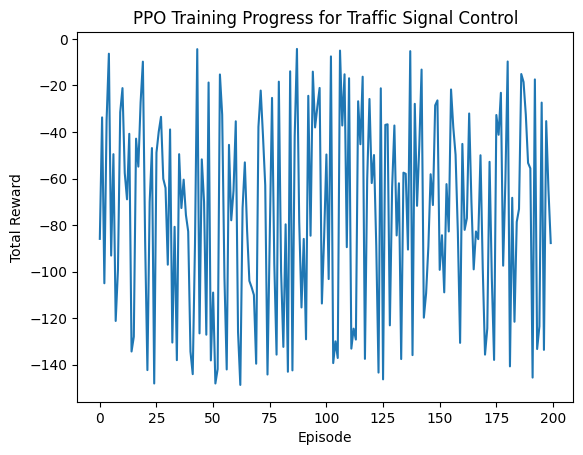

In [14]:
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training Progress for Traffic Signal Control")
plt.show()
